---
## Experiment 4 — Classical vs. Quantum Scaling: Fisher Information Efficiency

**Central claim**: QCNN parameters maintain tr(F_Q)/N = 1.0 (the theoretical maximum)
vs 0.006–0.11 for classical MLPs. With the correct encoding RY(x·π/4) and the pullback
QNG, QCNN+QNG_pb at n=5 reaches the classical MLP plateau (0.16 loss / 93% accuracy)
with 24 circuit parameters vs 65+.

**Architecture**: brick-wall QCNN (Pesah et al. 2021), data re-uploading, 2 layers.  
**Encoding**: RY(x·π/4) — maps standardised inputs [-2,2] to [-π/2,π/2], monotone.  
**Optimisers**: Adam (baseline) vs pullback QNG G_eff = (1/B)Σ p_i(1−p_i)(WJ_i)ᵀ(WJ_i).  
**Backend**: lightning.qubit (C++ state-vector simulator).


In [1]:
%load_ext autoreload
%autoreload 2

In [15]:
%matplotlib inline
import sys, importlib
import numpy as np
sys.path.insert(0, '.')
import exp4_mlp_vs_qcnn as exp4
importlib.reload(exp4)   # pick up any changes without restarting the kernel
import matplotlib.pyplot as plt

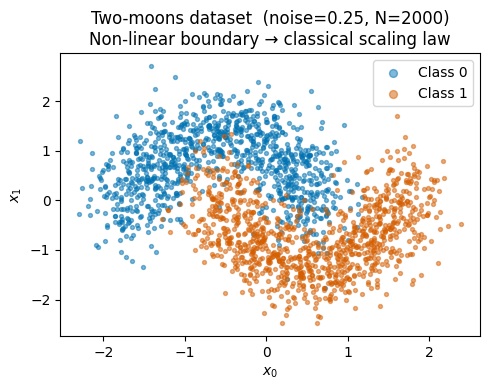

In [3]:
X, y = exp4.X, exp4.y

fig, ax = plt.subplots(figsize=(5, 4))
colors = ["#0072B2", "#D55E00"]
for cls, label in enumerate(["Class 0", "Class 1"]):
    mask = y == cls
    ax.scatter(X[mask, 0], X[mask, 1], s=8, alpha=0.5, color=colors[cls], label=label)
ax.set_xlabel("$x_0$")
ax.set_ylabel("$x_1$")
ax.set_title("Two-moons dataset  (noise=0.25, N=2000)\nNon-linear boundary → classical scaling law")
ax.legend(markerscale=2)
plt.tight_layout()
fig

In [18]:
N_STEPS_Q = 1000
LR_QNG_MIN = 1e-3

In [4]:
print("=" * 68)
print("A. Classical MLP family")
print("=" * 68)
c_res = [exp4.run_classical(h) for h in [2, 4, 8, 16, 32, 64]]

A. Classical MLP family
  MLP H=  2  n_params=   9  loss=0.30  acc=87%  tr/N=0.107
  MLP H=  4  n_params=  17  loss=0.31  acc=87%  tr/N=0.088
  MLP H=  8  n_params=  33  loss=0.17  acc=93%  tr/N=0.031
  MLP H= 16  n_params=  65  loss=0.16  acc=94%  tr/N=0.028
  MLP H= 32  n_params= 129  loss=0.16  acc=94%  tr/N=0.012
  MLP H= 64  n_params= 257  loss=0.16  acc=94%  tr/N=0.006


In [5]:
print("=" * 68)
print("B. QCNN + Adam")
print("=" * 68)
adam_res = [exp4.run_qcnn_adam(n) for n in exp4.Q_RANGE]

B. QCNN + Adam
  [QCNN+Adam] n=2…
    step    0  loss=0.7299  lr=0.01000
    step  100  loss=0.5344  lr=0.00994
    step  200  loss=0.3222  lr=0.00976
    step  300  loss=0.3716  lr=0.00946
    step  400  loss=0.2092  lr=0.00905
    step  500  loss=0.2899  lr=0.00854
    step  600  loss=0.2541  lr=0.00795
    step  700  loss=0.3091  lr=0.00729
    step  800  loss=0.1732  lr=0.00657
    step  900  loss=0.1437  lr=0.00582
    step 1000  loss=0.1421  lr=0.00504
    step 1100  loss=0.0995  lr=0.00427
    step 1200  loss=0.0958  lr=0.00351
    step 1300  loss=0.1600  lr=0.00280
    step 1400  loss=0.1256  lr=0.00213
    step 1500  loss=0.3165  lr=0.00154
    step 1600  loss=0.2608  lr=0.00104
    step 1700  loss=0.0964  lr=0.00064
    step 1800  loss=0.1356  lr=0.00034
    step 1900  loss=0.1637  lr=0.00016
    final  loss=0.19  acc=92%  tr/N=1.000
  [QCNN+Adam] n=3…
    step    0  loss=0.7811  lr=0.01000
    step  100  loss=0.3472  lr=0.00994
    step  200  loss=0.1979  lr=0.00976
    step

In [19]:
print("=" * 68)
print("C. QCNN + QNG_pb (pullback through W)")
print("=" * 68)
pb_res = [exp4.run_qcnn_qng_pb(n, n_steps=N_STEPS_Q, lr_qng_min=LR_QNG_MIN) for n in exp4.QNG_RANGE]

C. QCNN + QNG_pb (pullback through W)
  [QCNN+QNG_pb] n=2…
    step    0  loss=0.8410  lr_qng=0.00500
    step  100  loss=0.4756  lr_qng=0.00490
    step  200  loss=0.3379  lr_qng=0.00462
    step  300  loss=0.4192  lr_qng=0.00418
    step  400  loss=0.3538  lr_qng=0.00362
    step  500  loss=0.2373  lr_qng=0.00300
    step  600  loss=0.1600  lr_qng=0.00238
    step  700  loss=0.2139  lr_qng=0.00182
    step  800  loss=0.1600  lr_qng=0.00138
    step  900  loss=0.1925  lr_qng=0.00110
    final  loss=0.20  acc=92%
  [QCNN+QNG_pb] n=3…
    step    0  loss=0.6948  lr_qng=0.00500
    step  100  loss=0.3086  lr_qng=0.00490
    step  200  loss=0.1801  lr_qng=0.00462
    step  300  loss=0.1751  lr_qng=0.00418
    step  400  loss=0.3450  lr_qng=0.00362
    step  500  loss=0.1776  lr_qng=0.00300
    step  600  loss=0.0857  lr_qng=0.00238
    step  700  loss=0.1849  lr_qng=0.00182
    step  800  loss=0.0842  lr_qng=0.00138
    step  900  loss=0.1468  lr_qng=0.00110
    final  loss=0.17  acc=93%


In [20]:
print(f"\n{'Scenario':>20} {'n/H':>5} {'n_circ':>7} {'loss':>7} {'acc':>6}")
print("-" * 48)
for r in c_res:
    print(f"{'MLP':>20} {r['h']:>5}   {'–':>5} {r['test_loss']:>7.2f} {r['test_acc']:>6.0%}")
for r in adam_res:
    print(f"{'QCNN+Adam':>20} {r['n_qubits']:>5} {r['n_circ']:>7} {r['test_loss']:>7.2f} {r['test_acc']:>6.0%}")
for r in pb_res:
    print(f"{'QCNN+QNG_pb':>20} {r['n_qubits']:>5} {r['n_circ']:>7} {r['test_loss']:>7.2f} {r['test_acc']:>6.0%}")


            Scenario   n/H  n_circ    loss    acc
------------------------------------------------
                 MLP     2       –    0.30    87%
                 MLP     4       –    0.31    87%
                 MLP     8       –    0.17    93%
                 MLP    16       –    0.16    94%
                 MLP    32       –    0.16    94%
                 MLP    64       –    0.16    94%
           QCNN+Adam     2       9    0.19    92%
           QCNN+Adam     3      18    0.16    93%
           QCNN+Adam     4      27    0.17    94%
           QCNN+Adam     5      36    0.16    93%
           QCNN+Adam     6      45    0.17    94%
           QCNN+Adam     7      54    0.16    93%
           QCNN+Adam     8      63    0.17    93%
         QCNN+QNG_pb     2       9    0.20    92%
         QCNN+QNG_pb     3      18    0.17    93%
         QCNN+QNG_pb     4      27    0.17    93%
         QCNN+QNG_pb     5      36    0.17    94%
         QCNN+QNG_pb     6      45    0.17    93%


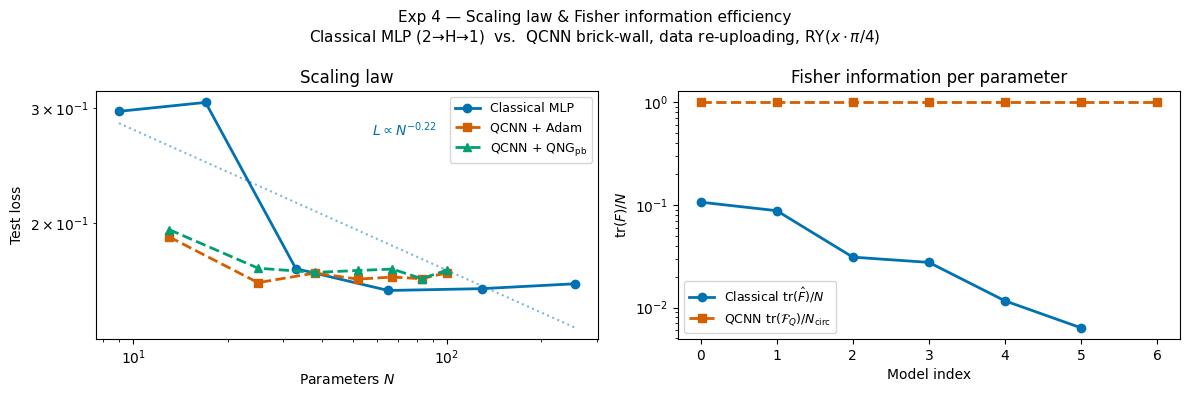

In [21]:
from scipy.stats import linregress

PAL   = {"c": "#0072B2", "adam": "#D55E00", "pb": "#009E73"}

def smooth(v, w=20):
    return np.convolve(v, np.ones(w) / w, mode="valid")

c_np  = [r["n_params"] for r in c_res]
c_l   = [r["test_loss"] for r in c_res]
c_tpn = [r["tr_f"] / r["n_params"] for r in c_res]
q_np  = [r["n_tot"] for r in adam_res]
q_l   = [r["test_loss"] for r in adam_res]
q_tpn = [r["tr_f"] / r["n_circ"] for r in adam_res]
p_np  = [r["n_tot"] for r in pb_res]
p_l   = [r["test_loss"] for r in pb_res]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(
    "Exp 4 — Scaling law & Fisher information efficiency\n"
    r"Classical MLP (2→H→1)  vs.  QCNN brick-wall, data re-uploading, $\mathrm{RY}(x\cdot\pi/4)$",
    fontsize=11,
)

ax = axes[0]
ax.loglog(c_np, c_l, "o-", color=PAL["c"], lw=2, label="Classical MLP")
sl, ic, *_ = linregress(np.log(c_np), np.log(c_l))
xf = np.geomspace(min(c_np), max(c_np), 200)
ax.loglog(xf, np.exp(ic) * xf**sl, ":", color=PAL["c"], alpha=0.5)
ax.text(0.55, 0.82, fr"$L \propto N^{{{sl:.2f}}}$", transform=ax.transAxes, color=PAL["c"], fontsize=10)
ax.loglog(q_np, q_l, "s--", color=PAL["adam"], lw=2, label="QCNN + Adam")
ax.loglog(p_np, p_l, "^--", color=PAL["pb"],   lw=2, label=r"QCNN + QNG$_\mathrm{pb}$")
ax.set_xlabel("Parameters $N$"); ax.set_ylabel("Test loss")
ax.set_title("Scaling law"); ax.legend(fontsize=9)

ax = axes[1]
ax.semilogy(range(len(c_res)), c_tpn, "o-", color=PAL["c"], lw=2,
            label=r"Classical $\mathrm{tr}(\hat{F})/N$")
ax.semilogy(range(len(adam_res)), q_tpn, "s--", color=PAL["adam"], lw=2,
            label=r"QCNN $\mathrm{tr}(\mathcal{F}_Q)/N_\mathrm{circ}$")
ax.set_xlabel("Model index"); ax.set_ylabel(r"$\mathrm{tr}(F)/N$")
ax.set_title("Fisher information per parameter"); ax.legend(fontsize=9)

plt.tight_layout()
fig

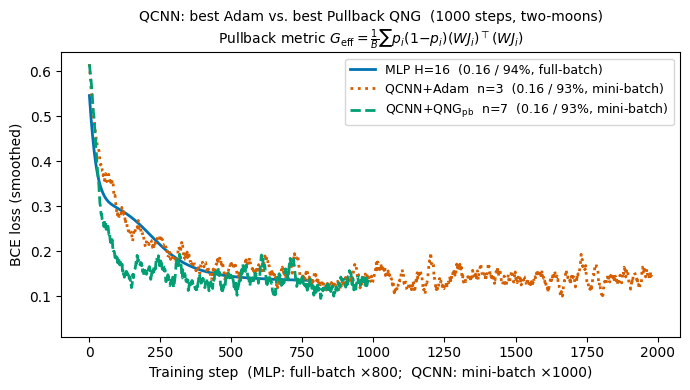

In [22]:
QNG_RANGE = exp4.QNG_RANGE

adam_by_n = {r["n_qubits"]: r for r in adam_res if r["n_qubits"] in QNG_RANGE}
pb_by_n   = {r["n_qubits"]: r for r in pb_res}

best_adam = min(adam_by_n.values(), key=lambda r: r["test_loss"])
best_pb   = min(pb_by_n.values(),   key=lambda r: r["test_loss"])
best_mlp  = min(c_res, key=lambda r: r["test_loss"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.set_title(
    f"QCNN: best Adam vs. best Pullback QNG  ({exp4.N_STEPS_Q} steps, two-moons)\n"
    r"Pullback metric $G_\mathrm{eff} = \frac{1}{B}\sum p_i(1{-}p_i)(WJ_i)^\top(WJ_i)$",
    fontsize=10,
)

for res, col, ls, lbl in [
    (best_mlp,  PAL["c"],    "-",
     f"MLP H={best_mlp['h']}  ({best_mlp['test_loss']:.2f} / {best_mlp['test_acc']:.0%}, full-batch)"),
    (best_adam, PAL["adam"], ":",
     f"QCNN+Adam  n={best_adam['n_qubits']}  ({best_adam['test_loss']:.2f} / {best_adam['test_acc']:.0%}, mini-batch)"),
    (best_pb,   PAL["pb"],   "--",
     f"QCNN+QNG$_{{\\rm pb}}$  n={best_pb['n_qubits']}  ({best_pb['test_loss']:.2f} / {best_pb['test_acc']:.0%}, mini-batch)"),
]:
    s = smooth(res["losses"])
    ax.plot(s, color=col, lw=2, ls=ls, label=lbl)

ax.set_xlabel(f"Training step  (MLP: full-batch ×{exp4.N_STEPS_C};  QCNN: mini-batch ×{exp4.N_STEPS_Q})")
ax.set_ylabel("BCE loss (smoothed)")
ax.legend(fontsize=9, loc="upper right")
ax.set_ylim(bottom=0.01)
plt.tight_layout()
fig